# Differential gene expression and GO term enrichment analysis

In [1]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from insitupy import InSituData, CACHE

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Load Xenium data into `InSituData` object

Now the Xenium data can be parsed by providing the data path to the `InSituPy` project folder.

In [4]:
insitupy_project = Path(CACHE / "out/demo_insitupy_project")

In [5]:
xd = InSituData.read(insitupy_project)

In [6]:
xd.load_images()
xd.load_cells()

In [7]:
xd

InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		C:\Users\ge37voy\.cache\InSituPy\out\demo_insitupy_project

    ➤ images
       CD20:	(25778, 35416)
       HE:	(25778, 35416, 3)
       HER2:	(25778, 35416)
       nuclei:	(25778, 35416)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 156447 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_publ_colors', 'cell_type_tacco_colors', 'counts_location', 'leiden', 'leiden_colors', 'log1p', 'neig

In [8]:
xd.import_annotations(
    files="../../demo_data/demo_annotations/demo_annotations.geojson",
    keys="Demo",
    scale_factor=0.2125
)

In [9]:
xd.import_regions(
    files="../../demo_data/demo_regions/demo_regions.geojson",
    keys="Demo",
    scale_factor=0.2125
)

### Visualize annotations
<img src="../../demo_data/demo_screenshots/napari_regions_annotations.jpg" class="center"/>

In [10]:
xd.show()

## Perform sample-level differential gene expression analysis using `InSituData`

In [11]:
from insitupy.tools import differential_gene_expression

### Scenario 1: Comparison of two annotations within one dataset

Exclude ambiguously assigned cells...
Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


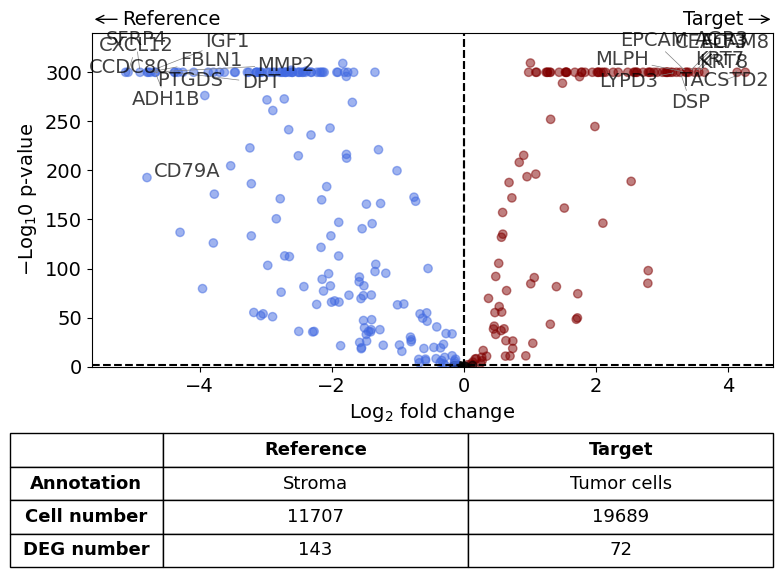

In [13]:
differential_gene_expression(
    target=xd,
    target_annotation_tuple=("Demo", "Tumor cells"),
    ref_annotation_tuple=("Demo", "Stroma"),
    ref=None,
    exclude_ambiguous_assignments=True,
    label_top_n=10
)

### Scenario 2: Comparison of two annotations within one dataset - restrict analysis to a specific region

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


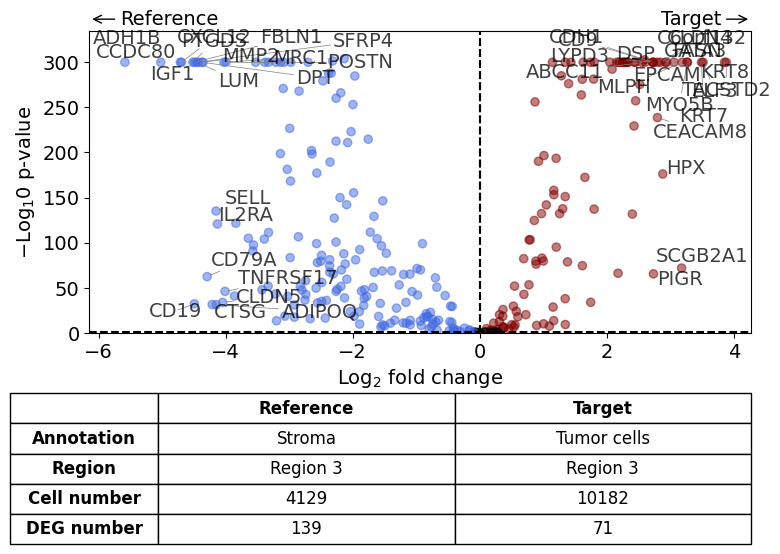

In [14]:
differential_gene_expression(
    target=xd,
    target_annotation_tuple=("Demo", "Tumor cells"),
    ref_annotation_tuple=("Demo", "Stroma"),
    ref=None,
    target_region_tuple=("Demo", "Region 3"),
    ref_region_tuple="same",
    exclude_ambiguous_assignments=True, # if a cell is assigned to both the annotation and the reference, it is used only for the annotation
)

## Experiment-level differential gene expression analysis

The clear structure of `InSituExperiment` lets us easily plan complex differential gene expression analysis across multiple samples. In the following, different Scenarios are shown how this can be done.

For more information on the `InSituExperiment` object see [here](../03_multisample_analysis/InSituPy_InSituExperiment.ipynb).

### Creating `InSituExperiment` object

In a first step the region annotations are used to split the dataset and create a `InSituExperiment` object.

In [15]:
from insitupy import InSituExperiment

In [17]:
exp = InSituExperiment.from_regions(
    data=xd,
    region_key="Demo",
    region_names=None # defaults to all regions
)
print(exp)

Region 1
Region 2
Region 3
InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     4148e351  ++-++  0001879  Replicate 1       Demo    Region 1
1     f4f2a485  ++-++  0001879  Replicate 1       Demo    Region 2
2     804e5604  ++-++  0001879  Replicate 1       Demo    Region 3


#### Scenario 1: Comparison of cell types between two samples

##### Scenario 1.1: Using the `InSituData` objects

First, the datasets of interest are extracted from the `InSituExperiment` object and subsequently processed using the `differential_gene_expression` function. In contrast to the previous examples we use now two different datasets.

In [18]:
xd0 = exp.data[0]
xd1 = exp.data[1]
xd2 = exp.data[2]

##### With one reference dataset

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


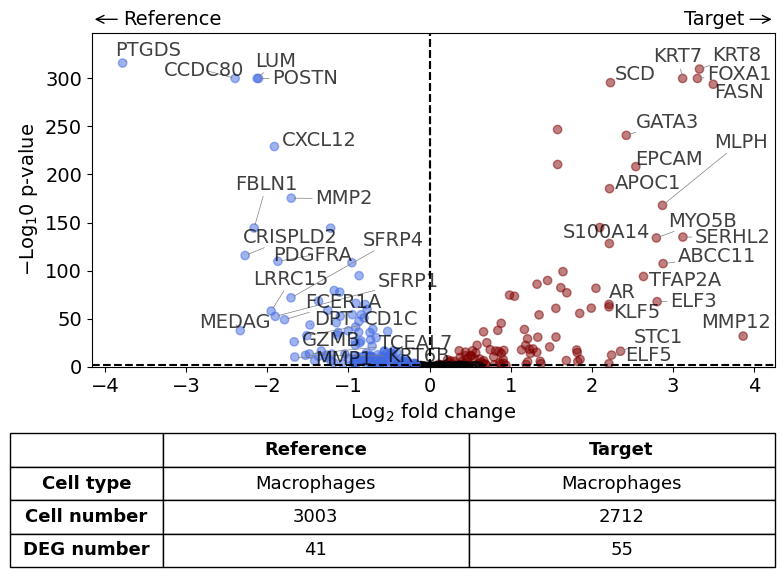

In [ ]:
differential_gene_expression(
    target=xd0,
    ref=xd1,
    target_cell_type_tuple=("cell_type_dc_sub", "Macrophages"),
    ref_cell_type_tuple="same",
    exclude_ambiguous_assignments=False, # in this case we are sure that there are no duplicate assignments
)

##### With list of reference datasets

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


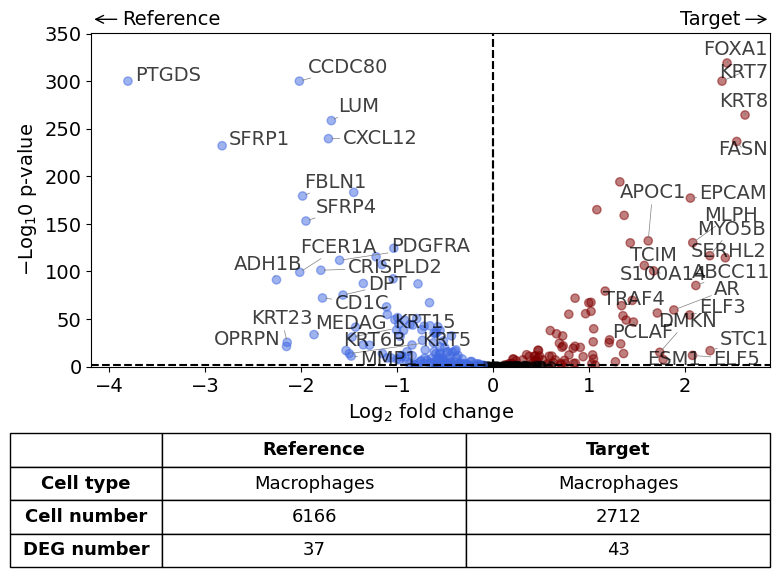

In [21]:
differential_gene_expression(
    target=xd0,
    ref=[xd1, xd2],
    target_cell_type_tuple=("cell_type_dc_sub", "Macrophages"),
    ref_cell_type_tuple="same",
    exclude_ambiguous_assignments=False, # if a cell is assigned to both the annotation and the reference, it is used only for the annotation
)

##### Scenario 1.2: Using the `InSituExperiment` objects

Instead of extracting the `InSituData` objects first, we can also perform the DGE analysis directly on the `InSituExperiment` object using its `dge()` function.

##### With one reference dataset

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


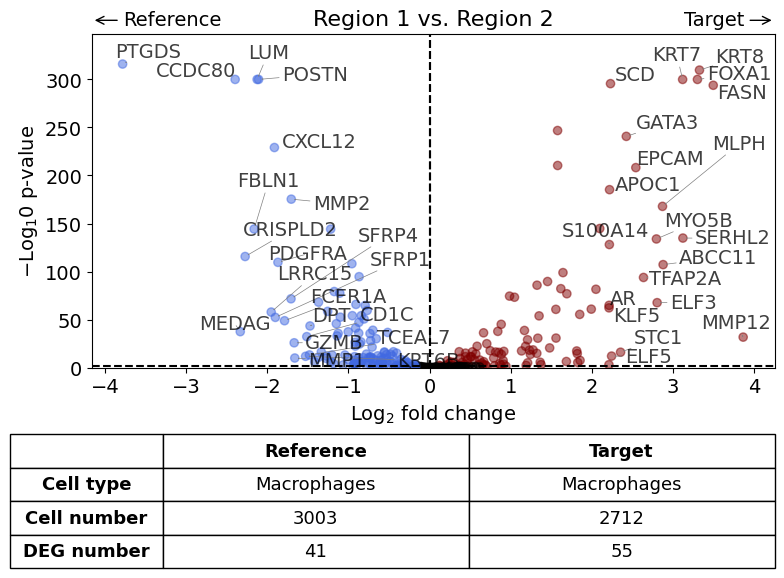

In [22]:
exp.dge(
    target_id=0,
    ref_id=1,
    target_cell_type_tuple=("cell_type_dc_sub", "Macrophages"),
    ref_cell_type_tuple="same",
    exclude_ambiguous_assignments=False,
    name_col="region_name"
)

##### With list of reference datasets

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


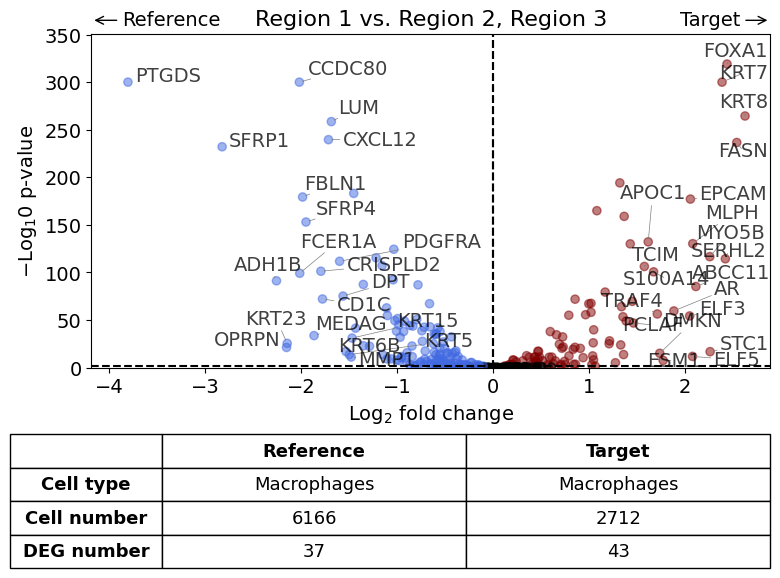

In [23]:
exp.dge(
    target_id=0,
    ref_id=[1,2],
    target_cell_type_tuple=("cell_type_dc_sub", "Macrophages"),
    ref_cell_type_tuple="same",
    name_col="region_name"
)

##### Against all other datasets as reference using `"rest"` argument

This should result in the same plot than the previous analysis

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


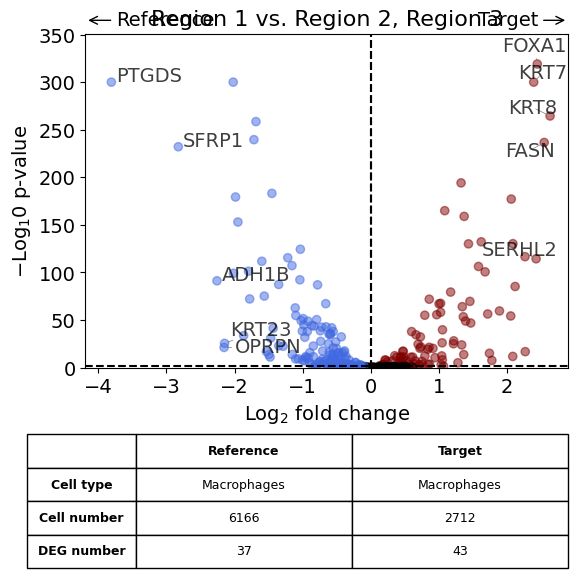

In [24]:
exp.dge(
    target_id=0,
    ref_id="rest",
    target_cell_type_tuple=("cell_type_dc_sub", "Macrophages"),
    ref_cell_type_tuple="same",
    exclude_ambiguous_assignments=True,
    name_col="region_name",
    figsize=(6,6),
    label_top_n=5,
    savepath="figures/dge_demo_region1_vs_rest.pdf"
)

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


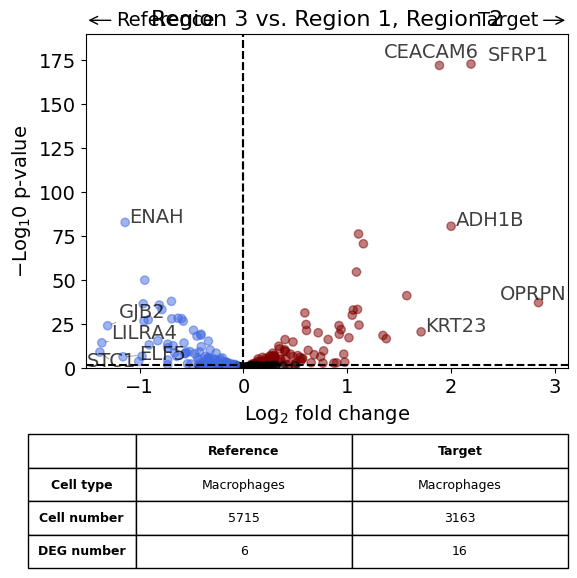

In [25]:
exp.dge(
    target_id=2,
    ref_id="rest",
    target_cell_type_tuple=("cell_type_dc_sub", "Macrophages"),
    ref_cell_type_tuple="same",
    exclude_ambiguous_assignments=True,
    name_col="region_name",
    figsize=(6,6),
    label_top_n=5,
    savepath="figures/dge_demo_region3_vs_rest.pdf"
)

#### Scenario 2: Comparison of cells within one annotation against all other cells - all within the same dataset

##### Scenario 2.1: Perform analysis taking all cell types together

This scenario is only uses one dataset but also works on the `InSituExperiment` level. The `name_col` argument can be used to specify which column of the metadata should be used for generating the title.

Exclude ambiguously assigned cells...
Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


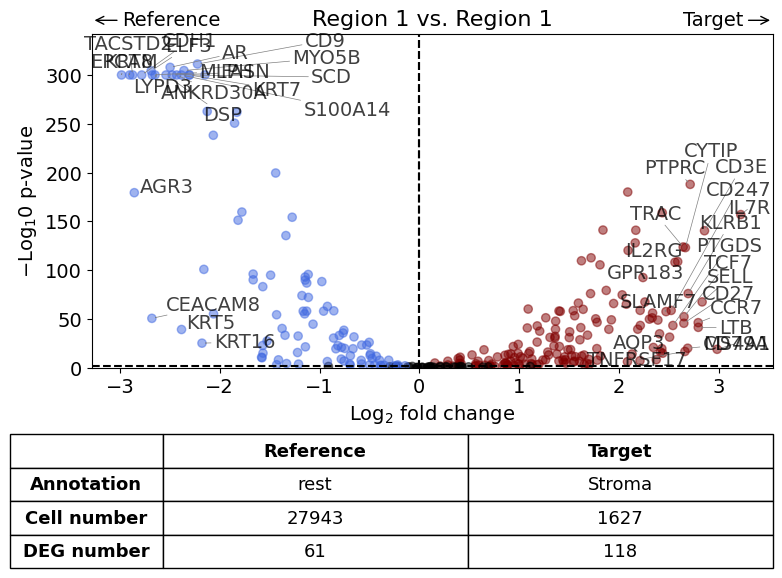

In [26]:
exp.dge(
    target_id=0,
    target_annotation_tuple=("Demo", "Stroma"),
    ref_annotation_tuple="rest",
    exclude_ambiguous_assignments=True,
    name_col="region_name",
)

#### Scenario 2: Comparison of cells within one annotation against all other cells - all within the same dataset but restricted to one cell type

##### Scenario 2.1: Perform analysis for one cell type only

This scenario is very similar to the first but the analysis is restricted to only one cell type (in this case Fibroblasts).

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


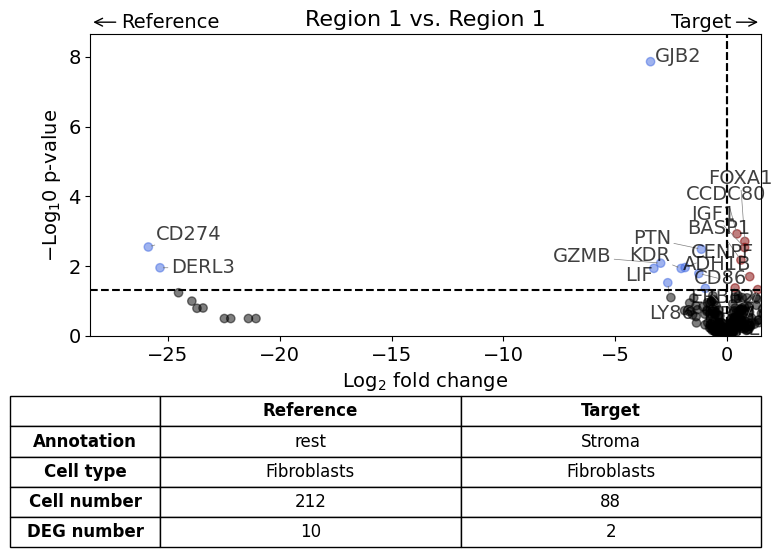

In [27]:
exp.dge(
    target_id=0,
    target_annotation_tuple=("Demo", "Stroma"),
    ref_annotation_tuple="rest",
    target_cell_type_tuple=("cell_type_dc", "Fibroblasts"),
    ref_cell_type_tuple="same",
    name_col="region_name",
)

#### Scenario 3: Comparison of two annotations between two regions or datasets - restrict analysis to one cell type

Here we compare the gene expression of one particular cell type (fibroblasts) in one histological annotation (Stroma) between two datasets. Further, we save the plot as PDF and restrict the number of labelled genes to 5.

In [28]:
annotation = "Stroma"
cell_type = "Fibroblasts"

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


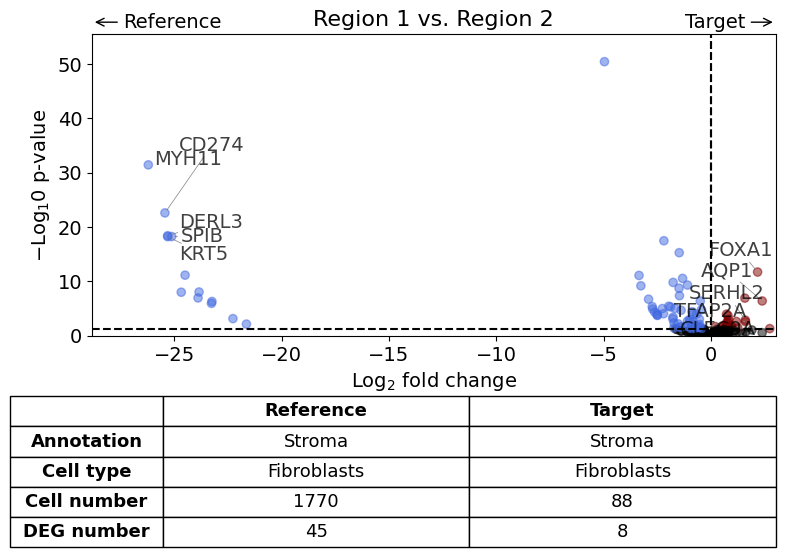

In [29]:

exp.dge(
    target_id=0,
    ref_id=1,
    target_annotation_tuple=("Demo", annotation),
    ref_annotation_tuple=("Demo", annotation),
    target_cell_type_tuple=("cell_type_dc", cell_type),
    ref_cell_type_tuple="same",
    name_col="region_name",
    label_top_n = 5,
    savepath="figures/volcano_demo.pdf"
)

#### Scenario 4: Return results instead of Volcano plot

In [30]:
dge = exp.dge(
    target_id=0,
    ref_id=1,
    target_annotation_tuple=("Demo", annotation),
    ref_annotation_tuple=("Demo", annotation),
    target_cell_type_tuple=("cell_type_tacco", cell_type),
    return_results=True,
    plot_volcano=False
)

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


In [31]:
dge.keys()

dict_keys(['results', 'params'])

In [32]:
dge_results = dge['results']

In [33]:
dge['params']

{'groupby': 'DGE_COMPARISON_COLUMN',
 'reference': 'REFERENCE',
 'method': 't-test',
 'use_raw': False,
 'layer': None,
 'corr_method': 'benjamini-hochberg'}

## GO term enrichment analysis

Gene ontology (GO) term enrichment analysis can be performed via three different analysis platforms: [g:Profiler](https://biit.cs.ut.ee/gprofiler/gost) and [Enrichr](https://maayanlab.cloud/Enrichr/).

As explained [here](https://biit.cs.ut.ee/gprofiler/page/docs#statistical_domain_scope) in case of panel-based technologies such as Xenium it is important to us a custom background gene list for the statistical analysis instead of all possible genes. Here, we used the overall gene list for this.

[STRINGdb](https://string-db.org/) is also implemented but does not allow to limit the background gene list. Therefore, this tool is not recommended to be used for Xenium data.

⚠️ **Attention**: Due to the low number of genes in a normal Xenium run, using GO term enrichment analysis with such datasets can be problematic. Please get in contact with statisticians to make sure it is ok to use this method with your data.

In [34]:
from insitupy.utils.go import GOEnrichment, get_up_down_genes
from insitupy.plotting.go import go_plot

In [35]:
genes_up, genes_down = get_up_down_genes(dge_results, pval_threshold=0.05, logfold_threshold=1)

In [36]:
background_genes = exp.data[0].cells.matrix.var_names.tolist()

In [37]:
# setup go term enrichment class
go = GOEnrichment()

# run go term enrichment analysis for up-regulated genes
go.gprofiler(target_genes=genes_up, key_added='up',
             top_n=20, organism="hsapiens", return_df=False,
             background=background_genes
             )
go.enrichr(target_genes=genes_up, key_added='up',
             top_n=20, organism="human", return_df=False,
             background=background_genes
             )

# for down-regulated genes
go.gprofiler(target_genes=genes_down, key_added='down',
             top_n=20, organism="hsapiens", return_df=False,
             background=background_genes
             )
go.enrichr(target_genes=genes_down, key_added='down',
             top_n=20, organism="human", return_df=False,
             background=background_genes
             )

The results are saved in the `GOEnrichment` class and can be accessed with the respective keys.

In [38]:
go

GOEnrichment analyses performed:
  gprofiler:
    - up
    - down
  enrichr:
    - up
    - down

Gprofiler does not return any significant results.

In [39]:
enrichment = go.results["gprofiler"]["up"]
enrichment.head()

,,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,Gene ratio,query,parents,intersections,evidences,Enrichment score


In [40]:
enrichment = go.results["gprofiler"]["down"]
enrichment.head()

,,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,Gene ratio,query,parents,intersections,evidences,Enrichment score


Enrichr does return significant results (before multiple testing correction).

In [41]:
enrichment = go.results["enrichr"]["down"]
enrichment.head()

source  \
query 0   GO_Biological_Process_2025   
      28  GO_Biological_Process_2025   
      30  GO_Biological_Process_2025   
      31  GO_Biological_Process_2025   
      32  GO_Biological_Process_2025   

                                               name   P-value  \
query 0    Negative Regulation of T Cell Activation  0.016985   
      28        Androgen Receptor Signaling Pathway  0.067340   
      30                     Protein Polymerization  0.067340   
      31  Regulation of Angiotensin Levels in Blood  0.067340   
      32         Sensory Perception of Bitter Taste  0.067340   

          Adjusted P-value  Old P-value  Old adjusted P-value  Odds Ratio  \
query 0           0.198346            0                     0    7.970588   
      28          0.198346            0                     0         inf   
      30          0.198346            0                     0         inf   
      31          0.198346            0                     0         inf   
      32          0.198346            0                     0         inf   

          Combined Score        intersections  Enrichment score      native  
query 0        32.483755  [CD274, SDC4, CTSG]          0.702576  GO:0050868  
      28             inf            [SCGB2A1]          0.702576  GO:0030521  
      30             inf               [KRT5]          0.702576  GO:0051258  
      31             inf               [CTSG]          0.702576  GO:0002002  
      32             inf               [PIGR]          0.702576  GO:0050913

In [42]:
enrichment = go.results["enrichr"]["up"]
enrichment.head()

source  \
query 0   GO_Biological_Process_2025   
      25  GO_Biological_Process_2025   
      27  GO_Biological_Process_2025   
      28  GO_Biological_Process_2025   
      29  GO_Biological_Process_2025   

                                                       name   P-value  \
query 0                     Regulation of Apoptotic Process  0.003486   
      25         Cellular Response to Amino Acid Starvation  0.040404   
      27                   fatty-acyl-CoA Metabolic Process  0.040404   
      28        Positive Regulation of Tooth Mineralization  0.040404   
      29  Positive Regulation of Cell-Cell Adhesion Medi...  0.040404   

          Adjusted P-value  Old P-value  Old adjusted P-value  Odds Ratio  \
query 0           0.124579            0                     0    9.678571   
      25          0.124579            0                     0         inf   
      27          0.124579            0                     0         inf   
      28          0.124579            0                     0         inf   
      29          0.124579            0                     0         inf   

          Combined Score                intersections  Enrichment score  \
query 0        54.770378  [FOXA1, TFAP2A, TCIM, FASN]          0.904557   
      25             inf                       [FASN]          0.904557   
      27             inf                       [FASN]          0.904557   
      28             inf                     [TFAP2A]          0.904557   
      29             inf                      [FOXA1]          0.904557   

              native  
query 0   GO:0042981  
      25  GO:0034198  
      27  GO:0035337  
      28  GO:0070172  
      29  GO:2000049

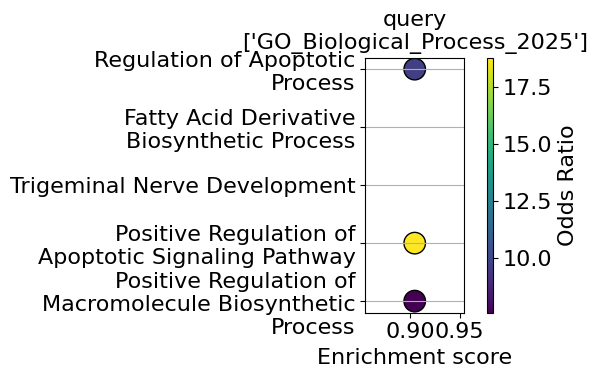

In [43]:
go_plot(enrichment=enrichment,
        style='dot',
        libraries='GO_Biological_Process_2025',
        color_key="Odds Ratio",
        max_to_plot=5,
        figsize=(6,4),
        #savepath="figures/go_demo.pdf"
        )

### GO term enrichment analysis for all three regions

In [44]:
up_list = []
down_list = []
for i in range(len(exp)):
    dge = exp.dge(
        target_id=i,
        ref_id="rest",
        target_cell_type_tuple=("cell_type_dc_sub", "Macrophages"),
        plot_volcano=False,
        return_results=True
    )
    genes_up, genes_down = get_up_down_genes(dge['results'], pval_threshold=0.05, logfold_threshold=1)
    up_list.append(genes_up)
    down_list.append(genes_down)

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.
Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.
Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


In [45]:
up_list

[['KRT7',
  'FOXA1',
  'KRT8',
  'FASN',
  'CCND1',
  'EPCAM',
  'ERBB2',
  'SCD',
  'MLPH',
  'APOC1',
  'GATA3',
  'MYO5B',
  'SERHL2',
  'TCIM',
  'S100A14',
  'ABCC11',
  'ENAH',
  'TENT5C',
  'ANKRD30A',
  'CTTN',
  'SH3YL1',
  'AR',
  'CD9',
  'TRAF4',
  'ELF3',
  'DSP',
  'TFAP2A',
  'PCLAF',
  'CDH1',
  'TOP2A',
  'KLF5',
  'OCIAD2',
  'CENPF',
  'STC1',
  'DMKN',
  'C6orf132',
  'TUBB2B',
  'ELF5',
  'LILRA4',
  'ESM1',
  'SOX17',
  'HPX',
  'SCGB2A1'],
 ['POSTN',
  'LUM',
  'CCDC80',
  'MMP2',
  'CXCL12',
  'CRISPLD2',
  'PDGFRB',
  'PDGFRA',
  'LRRC15',
  'MEDAG',
  'GJB2',
  'GZMB',
  'TCEAL7',
  'LTB'],
 ['SFRP1',
  'CEACAM6',
  'ADH1B',
  'PTGDS',
  'SERPINA3',
  'SFRP4',
  'KRT15',
  'OPRPN',
  'AQP1',
  'FCER1A',
  'CD1C',
  'LPL',
  'KRT23',
  'MMP12',
  'KRT14',
  'MYH11']]

In [46]:
# setup go term enrichment class
go = GOEnrichment()

for i, genes_up in enumerate(up_list):
    # run go term enrichment analysis for up-regulated genes
    go.enrichr(target_genes=genes_up, key_added=f'Region{i+1}_up',
                top_n=20, organism="Human", return_df=False,
                background=background_genes
                )

The results are saved in the `GOEnrichment` class and can be accessed with the respective keys.

In [47]:
go

GOEnrichment analyses performed:
  enrichr:
    - Region1_up
    - Region2_up
    - Region3_up

color_key 'Gene ratio' not found in columns.


C:\Users\ge37voy\Github\InSituPy\insitupy\plotting\go.py:140: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  s = axs[i].scatter(


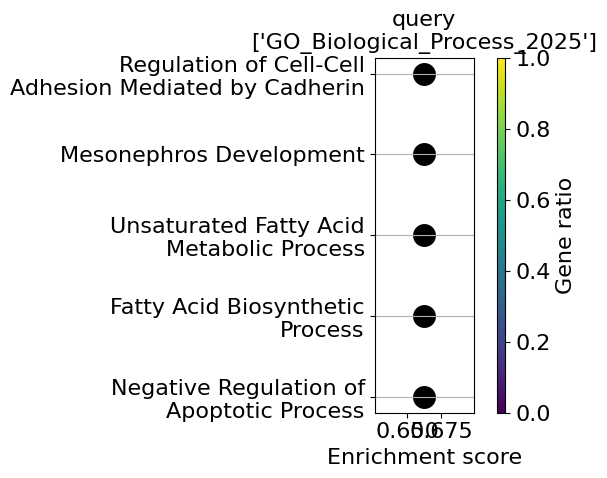

color_key 'Gene ratio' not found in columns.


C:\Users\ge37voy\Github\InSituPy\insitupy\plotting\go.py:140: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  s = axs[i].scatter(


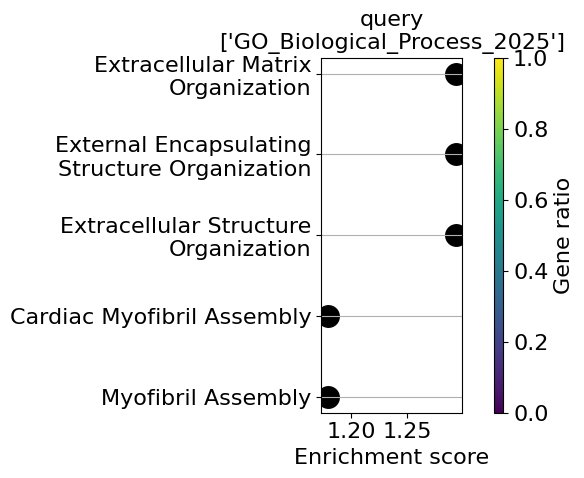

color_key 'Gene ratio' not found in columns.


C:\Users\ge37voy\Github\InSituPy\insitupy\plotting\go.py:140: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  s = axs[i].scatter(


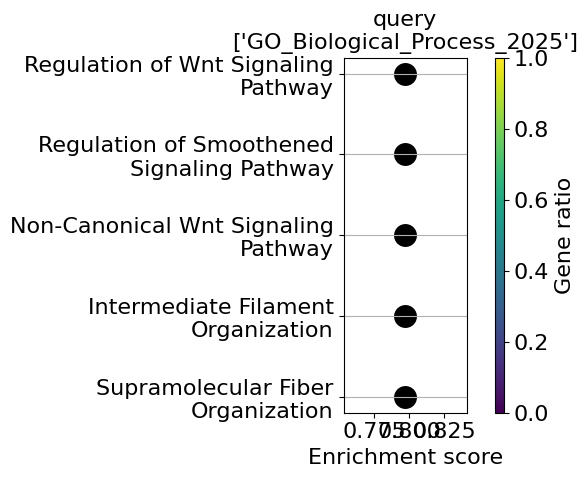

In [48]:
go_results = go.results["enrichr"]

for i, k in enumerate(go_results.keys()):
    enrichment = go_results[k]
    go_plot(enrichment=enrichment,
            style='dot',
            libraries='GO_Biological_Process_2025',
            max_to_plot=5,
            figsize=(6,5),
            #savepath=f"figures/go_demo_region{i+1}.pdf"
            )